In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Загружаем данные (убедитесь, что файл train.json загружен в папку /content/)
df = pd.read_json('train.json')

# Посмотрим на первые 5 строк
print(df.head())
# Проверим, какие кухни у нас есть
print(df['cuisine'].unique())

      id      cuisine                                        ingredients
0  10259        greek  [romaine lettuce, black olives, grape tomatoes...
1  25693  southern_us  [plain flour, ground pepper, salt, tomatoes, g...
2  20130     filipino  [eggs, pepper, salt, mayonaise, cooking oil, g...
3  22213       indian                [water, vegetable oil, wheat, salt]
4  13162       indian  [black pepper, shallots, cornflour, cayenne pe...
['greek' 'southern_us' 'filipino' 'indian' 'jamaican' 'spanish' 'italian'
 'mexican' 'chinese' 'british' 'thai' 'vietnamese' 'cajun_creole'
 'brazilian' 'french' 'japanese' 'irish' 'korean' 'moroccan' 'russian']


In [2]:
# 1. Функция для чистки ингредиентов
def clean_ingredients(ingredients_list):
    # Переводим в нижний регистр и заменяем пробелы на подчеркивания
    return ' '.join([i.lower().replace(' ', '_') for i in ingredients_list])

# Применяем чистку
df['ingredients_clean'] = df['ingredients'].apply(clean_ingredients)

# 2. Превращаем названия кухонь в числа
le = LabelEncoder()
y = le.fit_transform(df['cuisine'])

# Посмотрим, что получилось в таргете (первые 5 значений)
print("Пример закодированных кухонь:", y[:5])
print("Соответствие чисел и названий:", dict(zip(le.transform(le.classes_), le.classes_)))

# 3. Разделяем данные на тренировочные и тестовые (80% учимся, 20% проверяем)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['ingredients_clean'],
    y,
    test_size=0.2,
    random_state=42
)

print(f"\nДанные готовы! Обучающая выборка: {len(X_train_raw)} рецептов.")

Пример закодированных кухонь: [ 6 16  4  7  7]
Соответствие чисел и названий: {np.int64(0): 'brazilian', np.int64(1): 'british', np.int64(2): 'cajun_creole', np.int64(3): 'chinese', np.int64(4): 'filipino', np.int64(5): 'french', np.int64(6): 'greek', np.int64(7): 'indian', np.int64(8): 'irish', np.int64(9): 'italian', np.int64(10): 'jamaican', np.int64(11): 'japanese', np.int64(12): 'korean', np.int64(13): 'mexican', np.int64(14): 'moroccan', np.int64(15): 'russian', np.int64(16): 'southern_us', np.int64(17): 'spanish', np.int64(18): 'thai', np.int64(19): 'vietnamese'}

Данные готовы! Обучающая выборка: 31819 рецептов.


In [3]:
# Создаем инструмент для превращения текста в числа
# max_features=3000 означает, что мы берем 3000 самых важных ингредиентов
vectorizer = TfidfVectorizer(max_features=3000)

# Обучаем векторизатор на тренировочных данных и сразу трансформируем их
X_train = vectorizer.fit_transform(X_train_raw)

# Тестовые данные только трансформируем (используем "словарь", созданный на обучении)
X_test = vectorizer.transform(X_test_raw)

print(f"Матрица готова!")
print(f"Размер обучающей матрицы: {X_train.shape}")
# (Количество рецептов, Количество уникальных ингредиентов)

Матрица готова!
Размер обучающей матрицы: (31819, 3000)


In [4]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# Инициализируем 5 классификаторов из вашего списка
models_new = {
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, n_jobs=-1),
    "K Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Linear SVM": LinearSVC(),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, n_jobs=-1, verbosity=-1),
    "Dummy Classifier": DummyClassifier(strategy="most_frequent")
}

accuracy_results = {}

print("Obychenie modeley nachato...")

for name, model in models_new.items():
    # Обучение
    model.fit(X_train, y_train)
    # Предсказание
    y_pred = model.predict(X_test)
    # Расчет метрики
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# Определение лучшей модели
best_model_name = max(accuracy_results, key=accuracy_results.get)
print("\nRezultat:")
print(f"Luchshaya model: {best_model_name}")
print(f"Tochnost: {accuracy_results[best_model_name]:.4f}")

Obychenie modeley nachato...
Extra Trees: Accuracy = 0.7378
K Neighbors: Accuracy = 0.6255
Linear SVM: Accuracy = 0.7819


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: Accuracy = 0.7555
Dummy Classifier: Accuracy = 0.1970

Rezultat:
Luchshaya model: Linear SVM
Tochnost: 0.7819


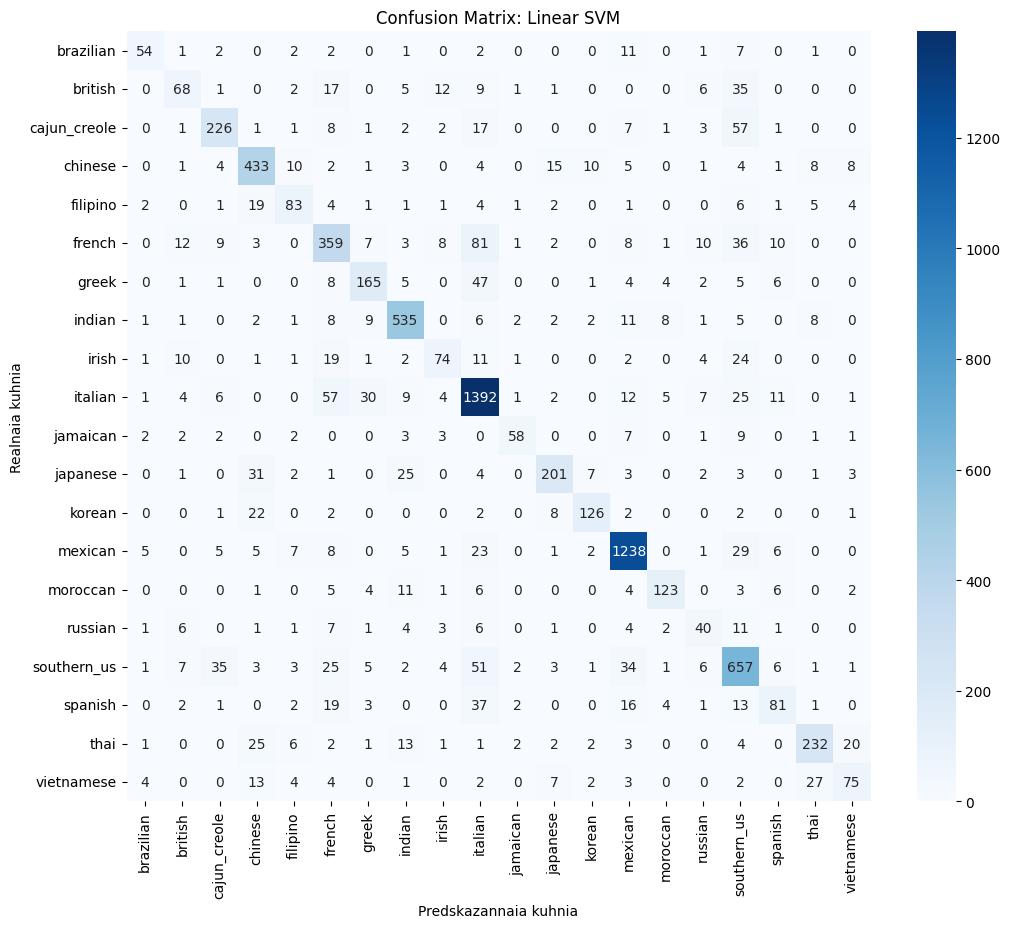

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Получаем предсказания лучшей модели
best_model = models_new["Linear SVM"]
y_pred_best = best_model.predict(X_test)

# 2. Строим матрицу
conf_mat = confusion_matrix(y_test, y_pred_best)

# 3. Отрисовка
plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix: Linear SVM')
plt.ylabel('Realnaia kuhnia')
plt.xlabel('Predskazannaia kuhnia')
plt.show()

In [6]:
# 1. Список ингредиентов для буррито
my_ingredients = 'tortilla, beans, meat, salsa'

# 2. Очистка (как при обучении: строчные буквы, замена пробелов на '_')
cleaned_input = ' '.join([i.strip().lower().replace(' ', '_') for i in my_ingredients.split(',')])

# 3. Превращение в вектор через наш обученный vectorizer
X_custom = vectorizer.transform([cleaned_input])

# 4. Предсказание лучшей моделью (Linear SVM)
prediction_numeric = best_model.predict(X_custom)

# 5. Перевод из числа обратно в название кухни
prediction_cuisine = le.inverse_transform(prediction_numeric)

print(f"Ingredienty: {my_ingredients}")
print(f"Rezultat: {prediction_cuisine[0].upper()}")

Ingredienty: tortilla, beans, meat, salsa
Rezultat: MEXICAN


In [7]:
import nltk
from nltk.stem import WordNetLemmatizer
import re

# Загружаем нужные компоненты
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def advanced_clean(ingredients_list):
    cleaned = []
    for i in ingredients_list:
        # Убираем цифры и лишние знаки, заменяем пробелы на _
        i = re.sub(r'[^a-zA-Z\s]', '', i)
        i = i.lower().strip().replace(' ', '_')
        # Приводим к начальной форме (лемма)
        i = lemmatizer.lemmatize(i)
        cleaned.append(i)
    return ' '.join(cleaned)

# Применяем новую очистку
df['ingredients_advanced'] = df['ingredients'].apply(advanced_clean)

# Заново разделяем данные
X_train_adv, X_test_adv, y_train, y_test = train_test_split(
    df['ingredients_advanced'], y, test_size=0.2, random_state=42
)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

# 1. Создаем цепочку: TF-IDF -> Linear SVC
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('svc', LinearSVC(max_iter=2000))
])

# 2. Параметры для перебора
# ngram_range (1, 2) заставит модель видеть пары слов (например, 'соевый_соус чеснок')
# C - это сила регуляризации (баланс между простотой и точностью)
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'svc__C': [0.1, 1, 10]
}

# 3. Запускаем поиск лучшей комбинации (используем cv=3 для ускорения)
grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_adv, y_train)

# 4. Вывод лучших параметров
print("\nLuchshie parametry:")
print(grid_search.best_params_)

# 5. Считаем финальную точность
best_final_model = grid_search.best_estimator_
y_pred_final = best_final_model.predict(X_test_adv)
final_acc = accuracy_score(y_test, y_pred_final)

print(f"\nStaraia tochnost (SVM): 0.7819")
print(f"Novaia tochnost (GridSearch + Lemmatization): {final_acc:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Luchshie parametry:
{'svc__C': 1, 'tfidf__ngram_range': (1, 1)}

Staraia tochnost (SVM): 0.7819
Novaia tochnost (GridSearch + Lemmatization): 0.7872


In [9]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# 1. Создаем три сильных компонента с лучшими параметрами
svm = LinearSVC(C=1, max_iter=2000)
lr = LogisticRegression(C=10, max_iter=1000) # C=10 хорошо работает для текстов
sgd = SGDClassifier(loss='modified_huber') # Этот лосс позволяет выдавать вероятности

# 2. Собираем их в ансамбль (голосование большинством)
ensemble = VotingClassifier(
    estimators=[
        ('svm', svm),
        ('lr', lr),
        ('sgd', sgd)
    ],
    voting='hard' # Простое большинство голосов
)

# 3. Финальный пайплайн с лучшим векторизатором
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 1))),
    ('ensemble', ensemble)
])

print("Obuchenie ansamblya nachato (eto zaymet okolo 1-2 minut)...")

# Обучаем на продвинутых данных (с лемматизацией)
final_pipeline.fit(X_train_adv, y_train)

# Проверка результата
y_pred_ensemble = final_pipeline.predict(X_test_adv)
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)

print(f"\nRezultaty:")
print(f"Tochnost odinochnogo SVM: 0.7872")
print(f"Tochnost ansamblya (Voting): {ensemble_acc:.4f}")

Obuchenie ansamblya nachato (eto zaymet okolo 1-2 minut)...

Rezultaty:
Tochnost odinochnogo SVM: 0.7872
Tochnost ansamblya (Voting): 0.7874
